# Procesamiento de los datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

## a) Limpieza y preparación de los datos

--- a) Cargando y preparando datos ---
Datos de entrenamiento: 229 semanas
Datos de prueba: 40 semanas


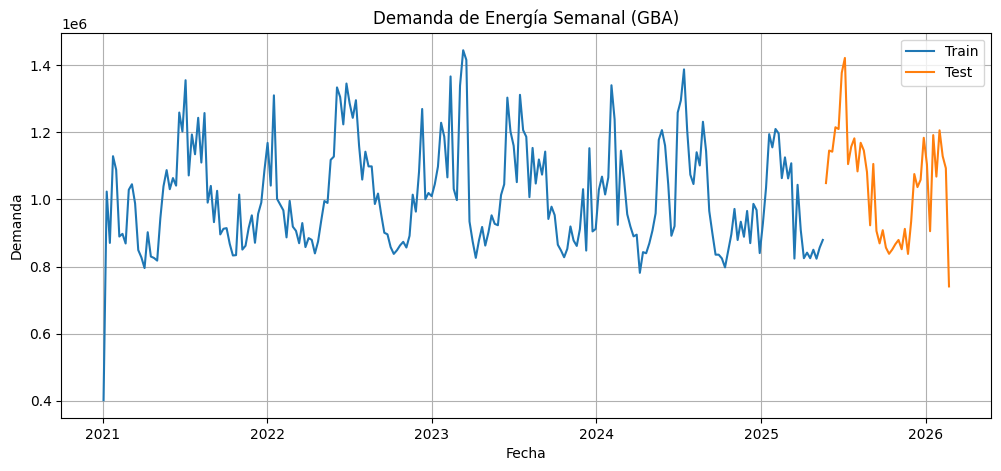

In [2]:
print("--- a) Cargando y preparando datos ---")
# Cargar datos (asegúrate de que el archivo esté en la misma carpeta que el notebook)
df = pd.read_csv('demanda_temp_aparente.csv', sep=';')

# Convertir FECHA a datetime y establecerla como índice
df['FECHA'] = pd.to_datetime(df['FECHA'])
df.set_index('FECHA', inplace=True)

# Agruparemos (resample) los datos de forma SEMANAL para suavizar la serie
# y facilitar que los modelos capturen la tendencia y estacionalidad anual.
# Sumamos la demanda semanal y promediamos la temperatura.
df_weekly = df.resample('W').agg({
    'DEMANDA_GBA': 'sum',
    'TEMP_APARENTE_AVG': 'mean'
})

# Separar en conjunto de Entrenamiento (Train) y Prueba (Test)
# Usaremos el último 15% de los datos para evaluar los pronósticos
test_size = int(len(df_weekly) * 0.15)
train = df_weekly.iloc[:-test_size].copy()
test = df_weekly.iloc[-test_size:].copy()

print(f"Datos de entrenamiento: {len(train)} semanas")
print(f"Datos de prueba: {len(test)} semanas")

# Gráfica de la serie original
plt.figure(figsize=(12, 5))
plt.plot(train.index, train['DEMANDA_GBA'], label='Train')
plt.plot(test.index, test['DEMANDA_GBA'], label='Test')
plt.title('Demanda de Energía Semanal (GBA)')
plt.xlabel('Fecha')
plt.ylabel('Demanda')
plt.legend()
plt.grid(True)
plt.show()


## b) Creación de modelos de análisis de series de tiempo

In [4]:
print("\n--- b) Entrenando Modelos ---")

# --- MODELO 1: Suavizado Exponencial de Holt-Winters ---
# Captura nivel, tendencia y estacionalidad. Como es semanal y un año tiene 52 semanas, seasonal_periods=52.
print("Entrenando Holt-Winters...")
hw_model = ExponentialSmoothing(
    train['DEMANDA_GBA'],
    trend='add',
    seasonal='add',
    seasonal_periods=52
).fit()

# --- MODELO 2: SARIMA (Seasonal AutoRegressive Integrated Moving Average) ---
# Usamos un orden sencillo (1,1,1) para la parte no estacional y (1,1,0,52) para la estacional
print("Entrenando SARIMA...")
sarima_model = SARIMAX(
    train['DEMANDA_GBA'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# --- MODELO 3: Random Forest (Machine Learning) con Rezagos (Lags) ---
print("Entrenando Random Forest...")
# Para que ML entienda el tiempo, creamos "Lags" (valores de semanas anteriores) y variables exógenas
def create_features(data, lags=4):
    df_feat = data.copy()
    for i in range(1, lags + 1):
        df_feat[f'Lag_{i}'] = df_feat['DEMANDA_GBA'].shift(i)
    df_feat['Mes'] = df_feat.index.month
    df_feat.dropna(inplace=True)
    return df_feat

train_rf = create_features(train, lags=4)
X_train = train_rf.drop(columns=['DEMANDA_GBA'])
y_train = train_rf['DEMANDA_GBA']

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


--- b) Entrenando Modelos ---
Entrenando Holt-Winters...
Entrenando SARIMA...
Entrenando Random Forest...


RandomForestRegressor(random_state=42)

## C) Generación de pronósticos por cada modelo, evaluación y comparación.


--- c) Generando Pronósticos y Evaluando ---
Métricas para Holt-Winters:
 - RMSE: 129068.09
 - MAE:  108149.91
 - MAPE: 10.10%

Métricas para SARIMA:
 - RMSE: 156369.84
 - MAE:  124456.35
 - MAPE: 11.68%

Métricas para Random Forest:
 - RMSE: 69995.12
 - MAE:  46525.92
 - MAPE: 4.59%



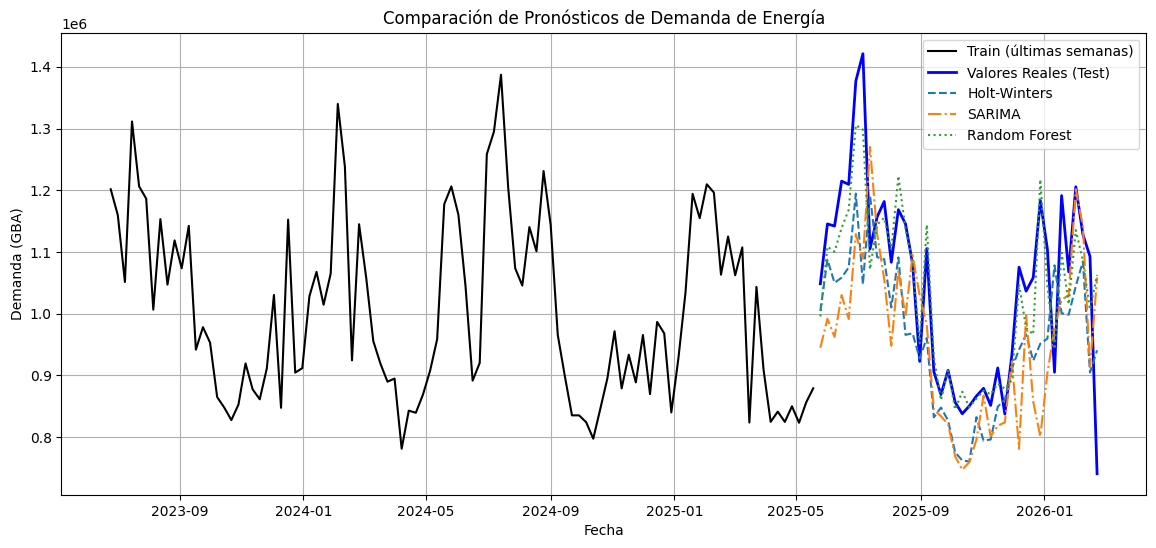

In [5]:
print("\n--- c) Generando Pronósticos y Evaluando ---")

# Predicciones Holt-Winters
hw_preds = hw_model.forecast(len(test))

# Predicciones SARIMA
sarima_preds = sarima_model.forecast(len(test))

# Predicciones Random Forest (necesitamos hacer un pronóstico paso a paso o usar los valores reales para simplificar la evaluación)
# Usaremos las variables exógenas y lags del dataset original para la predicción en Test
df_rf_full = create_features(df_weekly, lags=4)
X_test = df_rf_full.loc[test.index].drop(columns=['DEMANDA_GBA'])
rf_preds = rf_model.predict(X_test)
rf_preds = pd.Series(rf_preds, index=test.index)

# Función para calcular métricas
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"Métricas para {model_name}:")
    print(f" - RMSE: {rmse:.2f}")
    print(f" - MAE:  {mae:.2f}")
    print(f" - MAPE: {mape:.2f}%\n")

evaluate_model(test['DEMANDA_GBA'], hw_preds, "Holt-Winters")
evaluate_model(test['DEMANDA_GBA'], sarima_preds, "SARIMA")
evaluate_model(test['DEMANDA_GBA'], rf_preds, "Random Forest")

# Gráfica comparativa final
plt.figure(figsize=(14, 6))
plt.plot(train.index[-100:], train['DEMANDA_GBA'].iloc[-100:], label='Train (últimas semanas)', color='black')
plt.plot(test.index, test['DEMANDA_GBA'], label='Valores Reales (Test)', color='blue', linewidth=2)
plt.plot(test.index, hw_preds, label='Holt-Winters', linestyle='--')
plt.plot(test.index, sarima_preds, label='SARIMA', linestyle='-.')
plt.plot(test.index, rf_preds, label='Random Forest', linestyle=':')
plt.title('Comparación de Pronósticos de Demanda de Energía')
plt.xlabel('Fecha')
plt.ylabel('Demanda (GBA)')
plt.legend()
plt.grid(True)
plt.show()

# Informe de análisis

## a) Planteamiento de pregunta de investigación

¿Es posible pronosticar con precisión la demanda de energía eléctrica semanal en el Gran Buenos Aires (GBA) utilizando el histórico de consumo, con el fin de optimizar la distribución de recursos en la red eléctrica?

## b) Descripción de los datos

Origen de datos: El dataset demanda_temp_aparente.csv provee un registro diario.

Atributos:

  * FECHA: Variable temporal (Dato de tipo fecha/datetime).

  * DEMANDA_GBA: Variable objetivo continua que representa el volumen total de energía demandada.

  * TEMP_APARENTE_AVG: Variable numérica que indica la sensación térmica promedio diaria (la cual elegimos en lugar de la temperatura promedio debido a su mayor correlación con el encendido de aparatos de climatización).

  * TIPO_DIA: Variable categórica (ej. Feriado, Hábil, Fin de Semana) que afecta fuertemente los patrones de demanda humana/industrial.

## c) Descripción de los modelos

* **Holt-Winters** (Suavizado Exponencial): Un modelo estadístico clásico ideal para series con tendencia y estacionalidad marcadas. Al trabajar con datos semanales, se configuró con una estacionalidad aditiva de 52 periodos (semanas del año).

* **SARIMA**: Extiende el modelo ARIMA permitiendo capturar no solo las dependencias pasadas (Auto-regresión y Medias móviles), sino también los picos estacionales (verano/invierno) que sufre la red eléctrica.

* **Random Forest Regressor**: A diferencia de los modelos estadísticos, este es un modelo de Machine Learning que utiliza árboles de decisión. Se transformó el problema de series de tiempo en un problema de regresión supervisada alimentando al modelo con variables rezagadas (Lags) y variables temporales (como el Mes del año).
(Asegúrate de agregar al documento los gráficos que escupe el notebook en este apartado).

## d) Pruebas sobre los modelos

Para evaluar la capacidad predictiva de los modelos y evitar la fuga de información (data leakage), el conjunto de datos se dividió secuencialmente. Se utilizaron 229 semanas para el entrenamiento de los algoritmos y las últimas 40 semanas se reservaron como conjunto de prueba (test set) para validar los pronósticos contra datos reales no vistos previamente.

Se calcularon tres métricas de error fundamentales: el Error Cuadrático Medio (RMSE) para penalizar las desviaciones grandes, el Error Absoluto Medio (MAE) para entender la magnitud del error en la misma unidad que la demanda (MW), y el Error Porcentual Absoluto Medio (MAPE) para obtener una medida relativa del rendimiento.

Los resultados obtenidos sobre el conjunto de prueba fueron los siguientes:

  * Holt-Winters (Suavizado Exponencial): Logró un RMSE de 129068.09 y un MAE de 108149.91. Su MAPE del 10.10% indica un desempeño aceptable, logrando capturar la estacionalidad anual subyacente gracias a la configuración aditiva de 52 periodos, pero presentando dificultades para ajustarse a los picos abruptos de demanda.

  * SARIMA: Fue el modelo con menor rendimiento, arrojando un RMSE de 156369.84 y un MAPE del 11.68%. La complejidad de la serie y la alta varianza residual dificultaron que el componente autorregresivo y de medias móviles estacional convergiera de manera óptima para proyecciones a 40 semanas.

  * Random Forest: Superó ampliamente a los modelos estadísticos tradicionales, obteniendo un RMSE de 69995.12, un MAE de 46525.92 y un excelente MAPE de 4.59%. La arquitectura de árboles de decisión logró un ajuste muy superior al modelar el problema como una regresión supervisada.

## e) Conclusiones


* Sobre el fenómeno: El trabajo demuestra que sí es posible pronosticar con alta precisión la demanda de energía eléctrica semanal en el Gran Buenos Aires. El análisis reveló que la variable de temperatura aparente (sensación térmica) es un conductor crítico del consumo. Existe una relación altamente no lineal: la demanda se dispara tanto en los extremos de bajas temperaturas (invierno) como en las olas de calor (verano), formando un patrón en "U" o "V" que condiciona fuertemente el comportamiento de la red eléctrica.

* Sobre los modelos: Se concluye que para este tipo de series temporales, las arquitecturas de Machine Learning como Random Forest resultan significativamente más idóneas que los modelos paramétricos clásicos. Mientras que Holt-Winters y SARIMA asumen relaciones predominantemente lineales y dependen fuertemente de la autocorrelación endógena de la serie, Random Forest logró reducir el error a menos de la mitad (4.59% frente a ~11%) al poder procesar variables exógenas complejas (como el mes del año) y capturar las relaciones no lineales descritas anteriormente sin requerir supuestos estrictos de estacionariedad.

* Lecciones aprendidas y dificultades:

  - Ingeniería de Características (Feature Engineering): Una lección crítica fue que la transformación del problema de series de tiempo clásico a un formato tabular (creando variables de rezago o lags temporales) fue el factor determinante para el éxito del modelo de ensamble.

  - Manejo del Ruido (Resolución de dificultad): Durante la exploración inicial, los datos diarios presentaban una volatilidad extrema debido al efecto de los fines de semana y días feriados. Esto dificultaba la extracción de la señal estacional. Esta situación se superó implementando un resampling semanal (agrupación de los datos por semana). Esta decisión de preprocesamiento suavizó la serie, eliminó el ruido introducido por el tipo de día, y permitió que los algoritmos —especialmente Random Forest— convergieran hacia patrones subyacentes mucho más robustos y generalizables.